# Taller 01: Adquisición, procesamiento y visualización de datos
**Maestría en Ciencia de Datos, Universidad Yachay Tech**
**Asignatura:** Fundamentos de Ciencia de Datos
**Estudiante:** Alexander Omar Fernández Pérez
**Dataset:** Online Retail (UCI Machine Learning Repository, id 352)

Este taller sigue las fases del ciclo de vida de un proyecto de ciencia de datos:
1. **Recopilación de datos:** descarga y lectura del archivo original.
2. **Limpieza y preprocesamiento:** justificando cada decisión, y carga en SQLite.
3. **Análisis exploratorio (EDA):** descripción de los datos y metadatos.
4. **Comunicación:** tres visualizaciones y la historia que cuentan.

## Paso 0: Preparación del entorno


### 0.2 Importación de librerías

In [1]:
import sqlite3                      # base de datos SQLite 
import zipfile                      # abrir archivos .zip 
from pathlib import Path            # manejo de rutas de carpetas y archivos
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests

warnings.filterwarnings("ignore")                          # oculta avisos menores
pd.set_option("display.max_columns", None)                 # mostrar todas las columnas
pd.set_option("display.float_format", "{:,.2f}".format)    # números con 2 decimales

print("pandas:", pd.__version__)

pandas: 2.3.2


### 0.3 Estructura de carpetas
Todas las rutas se definen en un solo lugar para reutilizarlas en el resto del notebook.

```
1_taller_fundamentos_cienciadedatos/
├── Taller01_Online_Retail.ipynb      ← este notebook
├── data/
│   ├── raw/                          ← archivo original (no se modifica)
│   └── online_retail.db              ← base SQLite con los datos limpios
├── descripcion_dataset.txt           ← descripción del dataset (Parte 2)
└── *.png                             ← visualizaciones (Parte 3)
```

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR  = DATA_DIR / "raw"

RAW_ZIP  = RAW_DIR / "online_retail.zip"      # archivo descargado
RAW_XLSX = RAW_DIR / "Online Retail.xlsx"     # Excel dentro del zip
DB_PATH  = DATA_DIR / "online_retail.db"      # base de datos SQLite
TXT_PATH = BASE_DIR / "descripcion_dataset.txt"

RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta de trabajo:", BASE_DIR)
print("Carpeta de datos  :", RAW_DIR, "->", RAW_DIR.exists())

Carpeta de trabajo: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos
Carpeta de datos  : c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\data\raw -> True


# Parte 1: Adquisición y limpieza de datos

## Paso 1: Adquisición y diagnóstico

### 1.1 Descarga del dataset
Se descarga el archivo comprimido desde el repositorio UCI y se extrae el Excel en `data/raw/`.


In [3]:
URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

if RAW_XLSX.exists():
    print("El archivo ya existe, no se vuelve a descargar.")
else:
    print("Descargando...")
    respuesta = requests.get(URL, timeout=120)
    respuesta.raise_for_status()
    RAW_ZIP.write_bytes(respuesta.content)

    with zipfile.ZipFile(RAW_ZIP) as z:
        print("Contenido del zip:", z.namelist())
        z.extractall(RAW_DIR)

print("Archivo listo:", RAW_XLSX.exists())
print(f"Tamaño: {RAW_XLSX.stat().st_size / 1e6:.1f} MB")

El archivo ya existe, no se vuelve a descargar.
Archivo listo: True
Tamaño: 23.7 MB


### 1.2 Lectura del archivo
Se carga el Excel en un **DataFrame** (la tabla de pandas).

In [4]:
df_raw = pd.read_excel(RAW_XLSX, dtype={"InvoiceNo": str, "StockCode": str})

print("Filas y columnas:", df_raw.shape)
df_raw.head()

Filas y columnas: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


### 1.3 Diagnóstico: tipos de datos, valores faltantes y estadísticas

In [69]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [70]:
faltantes = pd.DataFrame({
    "faltantes": df_raw.isna().sum(),
    "porcentaje": (df_raw.isna().mean() * 100).round(2)
})
faltantes

,faltantes,porcentaje
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [71]:
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386048,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"




Nota: el dataset mezcla ventas reales con cancelaciones, ajustes contables y cargos que no son productos. La limpieza debe separarlos.

### 1.4 Cuantificación de problemas específicos
Se cuenta cuántas filas tiene cada problema, para que cada decisión de limpieza tenga un número que la respalde. Los problemas se superponen.

In [72]:
diagnostico = pd.DataFrame({
    "problema": ["Filas duplicadas", "Facturas canceladas (C)", "Cantidad negativa",
                 "Precio = 0", "Precio < 0", "Sin CustomerID", "Sin Description"],
    "filas": [df_raw.duplicated().sum(),
              df_raw["InvoiceNo"].str.startswith("C").sum(),
              (df_raw["Quantity"] < 0).sum(),
              (df_raw["UnitPrice"] == 0).sum(),
              (df_raw["UnitPrice"] < 0).sum(),
              df_raw["CustomerID"].isna().sum(),
              df_raw["Description"].isna().sum()]
})
diagnostico["% del total"] = (diagnostico["filas"] / len(df_raw) * 100).round(2)
diagnostico

,problema,filas,% del total
0,Filas duplicadas,5268,0.97
1,Facturas canceladas (C),9288,1.71
2,Cantidad negativa,10624,1.96
3,Precio = 0,2515,0.46
4,Precio < 0,2,0.00
5,Sin CustomerID,135080,24.93
6,Sin Description,1454,0.27


## Paso 2: Limpieza de datos

Cada decisión sigue el mismo patrón: **(1) qué se encontró**, **(2) evidencia**, **(3) interpretación** y **(4) decisión**.

In [73]:
df = df_raw.copy()

registro = []

def registrar(paso, antes, despues):
    registro.append({"paso": paso, "filas_antes": antes,
                     "filas_despues": despues, "eliminadas": antes - despues})
    print(f"{paso}: {antes:,} → {despues:,} filas (se eliminaron {antes - despues:,})")

### 2.1 Decisión 1: Eliminar duplicados exactos

In [74]:
antes = len(df)
df = df.drop_duplicates()
registrar("1. Duplicados exactos", antes, len(df))

1. Duplicados exactos: 541,909 → 536,641 filas (se eliminaron 5,268)


### 2.2 Decisión 2: Separar las cancelaciones
Las facturas con "C" son cancelaciones. No se descartan: se guardan en `df_cancel` porque se usan en el paso siguiente y se cargan en su propia tabla de SQLite.

In [75]:
es_cancelacion = df["InvoiceNo"].str.startswith("C")

df_cancel = df[es_cancelacion].copy()
antes = len(df)
df = df[~es_cancelacion].copy()

registrar("2. Cancelaciones (separadas)", antes, len(df))

2. Cancelaciones (separadas): 536,641 → 527,390 filas (se eliminaron 9,251)


### 2.3 Decisión 3: Descontar las compras anuladas por cancelaciones

**El problema.** Cada cancelación deja **dos filas** en los datos:

| InvoiceNo | Producto | Quantity | ¿Qué es? |
|---|---|---|---|
| 581483 | Paper craft, little birdie | +80.995 | La **compra** original |
| C581484 | Paper craft, little birdie | −80.995 | La **cancelación** que la anula |

En la Decisión 2 solo salió la fila con "C". La compra original **sigue en `df`** como si se hubiera vendido. Hay que encontrar, para cada cancelación, la compra que anuló.

**Alternativa descartada: emparejar por número de factura.** Se probó si la cancelación lleva el mismo número que la compra, con una "C" delante. La celda siguiente muestra que **ninguna** coincide: la tienda usa una sola numeración correlativa para todos sus documentos, y la "C" solo indica el tipo de documento (por ejemplo, la compra 581483 fue anulada por la C581484).

| Código | Qué hace |
|---|---|
| `.str[1:]` | Quita el primer carácter: `"C581484"` → `"581484"`. |
| `set(...)` | Conjunto con los números de las facturas de venta, para buscar rápido. |
| `sum(n in num_ventas for n in num_cancel)` | Para cada número de cancelación pregunta si existe una venta con ese número y cuenta los "sí". |

In [76]:
num_cancel = df_raw.loc[df_raw["InvoiceNo"].str.startswith("C"), "InvoiceNo"].str[1:].unique()
num_ventas = set(df_raw.loc[~df_raw["InvoiceNo"].str.startswith("C"), "InvoiceNo"])

coinciden = sum(n in num_ventas for n in num_cancel)
print("Facturas de cancelación distintas:", len(num_cancel))
print("Con una venta del mismo número:   ", coinciden)

Facturas de cancelación distintas: 3836
Con una venta del mismo número:    0


**Método elegido.** El dataset no tiene ninguna columna que conecte una cancelación con su compra, así que el emparejamiento se **reconstruye**. Se tomó como base el método del notebook de referencia más citado para este dataset (*Customer Segmentation*, Fabien Daniel, Kaggle), que busca la compra del **mismo cliente y producto, anterior a la cancelación**, y registra las unidades anuladas en una columna `QuantityCanceled` en vez de borrar la compra. Así se tratan también las **cancelaciones parciales** (por ejemplo, compró 24 y devolvió 6).

**Reglas, para cada cancelación:**

1. Se buscan compras del **mismo cliente y producto**, hechas **antes** (o en el mismo momento) que la cancelación.
2. **Intento 1, pareja exacta:** entre esas compras, la más reciente con la **misma cantidad y precio** y que todavía no tenga unidades anuladas.
3. **Intento 2, pareja aproximada:** si no hay exacta, la compra más reciente que todavía tenga **unidades suficientes** para descontar.
4. Las unidades canceladas se suman en `QuantityCanceled` de esa compra.

**Casos que no se pueden emparejar:**

- **Sin cliente:** no hay forma de saber de quién era la compra.
- **Descuentos** (código `D`): no son productos; solo existen como cancelaciones.
- **Sin compra previa:** el cliente no compró ese producto antes dentro del periodo (probablemente lo compró antes del 1 de diciembre de 2010).
- **Cantidad insuficiente:** las compras previas no alcanzan para cubrir la cantidad cancelada.

**¿Qué hace el código? (paso a paso)**

**Preparación**

| Código | Qué hace |
|---|---|
| `df_cancel[... .notna() & (... != "D")]` | Cancelaciones con cliente que no son descuentos. `&` significa "y". |
| `.sort_values("InvoiceDate", kind="stable")` | Ordena por fecha. `kind="stable"` hace que, ante empates, el orden sea siempre el mismo (resultado reproducible en cualquier computadora). |
| `compras.groupby(["CustomerID", "StockCode"])` | Agrupa las compras por **(cliente, producto)**. |
| `grupos = {clave: grupo ...}` | Un **diccionario**: dada la pareja (cliente, producto), devuelve al instante sus compras. Evita buscar en las 527.000 filas cada vez. |
| `.to_dict()` | Convierte una columna en diccionario {número de fila: valor}, para consultar rápido la cantidad y el precio de cada compra. |
| `dict.fromkeys(df.index, 0)` | Diccionario con **0 unidades anuladas** para cada compra, que se irá llenando. |

**El ciclo (`for`)**: recorre las cancelaciones una por una.

| Código | Qué hace |
|---|---|
| `q = -fila["Quantity"]` | Unidades canceladas en positivo (−80.995 → 80.995). |
| `grupos.get((cliente, producto))` | Busca las compras de ese cliente y producto. Si no hay, `get` devuelve `None`. |
| `grupo.index[grupo["InvoiceDate"] <= fecha]` | Números de fila de las compras anteriores a la cancelación. |
| `[::-1]` | Invierte el orden: la **más reciente primero**. |
| `next((i for i in candidatas if ...), None)` | Recorre las candidatas y devuelve la **primera** que cumple la condición; si ninguna la cumple, devuelve `None`. |
| `anulado[elegida] += q` | Suma las unidades canceladas a esa compra. |
| `resultado[idx_c] = "..."` | Anota cómo se resolvió cada cancelación. |

**Al final:**

| Código | Qué hace |
|---|---|
| `df["QuantityCanceled"] = pd.Series(anulado)` | Crea la columna con las unidades anuladas de cada compra (0 si no tuvo cancelaciones). |
| `df_cancel["Emparejamiento"] = ...` | Guarda en la tabla de cancelaciones cómo se resolvió cada una. |
| `.fillna(...)` + `.where(...)` | Etiqueta las que no entraron al ciclo: sin cliente o descuento. |

Esta celda tarda alrededor de **1 minuto**.

In [77]:
# ---------- Preparación ----------
# Cancelaciones con cliente y que no son descuentos, en orden cronológico
canc = df_cancel[df_cancel["CustomerID"].notna() & (df_cancel["StockCode"] != "D")]
canc = canc.sort_values("InvoiceDate", kind="stable")

# Compras agrupadas por (cliente, producto), ordenadas por fecha
compras = df[df["Quantity"] > 0].sort_values("InvoiceDate", kind="stable")
grupos = {clave: grupo for clave, grupo in compras.groupby(["CustomerID", "StockCode"])}

cantidad = df["Quantity"].to_dict()        # cantidad comprada en cada fila
precio   = df["UnitPrice"].to_dict()       # precio de cada fila
anulado  = dict.fromkeys(df.index, 0)      # unidades anuladas de cada compra (empieza en 0)
resultado = {}                             # cómo se resolvió cada cancelación

# ---------- Emparejamiento ----------
for idx_c, fila in canc.iterrows():
    q = -fila["Quantity"]                                        # unidades canceladas
    grupo = grupos.get((fila["CustomerID"], fila["StockCode"]))

    if grupo is None:
        resultado[idx_c] = "Sin compra previa"
        continue

    # Compras anteriores a la cancelación, de la más reciente a la más antigua
    candidatas = grupo.index[grupo["InvoiceDate"] <= fila["InvoiceDate"]][::-1]
    if len(candidatas) == 0:
        resultado[idx_c] = "Sin compra previa"
        continue

    # Intento 1: pareja exacta (misma cantidad y precio, sin anulaciones previas)
    elegida = next((i for i in candidatas
                    if anulado[i] == 0 and cantidad[i] == q and precio[i] == fila["UnitPrice"]), None)
    tipo = "Exacta"

    # Intento 2: la más reciente con unidades suficientes
    if elegida is None:
        elegida = next((i for i in candidatas if cantidad[i] - anulado[i] >= q), None)
        tipo = "Aproximada"

    if elegida is None:
        resultado[idx_c] = "Cantidad insuficiente"
        continue

    anulado[elegida] += q
    resultado[idx_c] = tipo

# ---------- Resultados ----------
df["QuantityCanceled"] = pd.Series(anulado)

df_cancel["Emparejamiento"] = pd.Series(resultado)
df_cancel["Emparejamiento"] = df_cancel["Emparejamiento"].fillna("Sin cliente")
df_cancel["Emparejamiento"] = df_cancel["Emparejamiento"].where(df_cancel["StockCode"] != "D", "Descuento")

print("Cancelaciones procesadas:", len(df_cancel))

Cancelaciones procesadas: 9251


**Resultado del emparejamiento.** `value_counts()` cuenta cuántas cancelaciones quedaron en cada categoría. En el notebook de referencia de Kaggle se reportan **1.226** cancelaciones sin compra de origen; aquí debe salir la misma cifra en "Sin compra previa", lo que confirma que la lógica base es equivalente.

In [78]:
resumen_emparejamiento = df_cancel["Emparejamiento"].value_counts().to_frame("cancelaciones")
resumen_emparejamiento["%"] = (resumen_emparejamiento["cancelaciones"] / len(df_cancel) * 100).round(1)
resumen_emparejamiento

,cancelaciones,%
Emparejamiento,,
Aproximada,4687,50.70
Exacta,2758,29.80
Sin compra previa,1226,13.30
Sin cliente,379,4.10
Cantidad insuficiente,124,1.30
Descuento,77,0.80


**Efecto sobre las compras.** Se clasifica cada compra según cuánto se le anuló:

In [79]:
total   = (df["Quantity"] > 0) & (df["QuantityCanceled"] == df["Quantity"])
parcial = (df["QuantityCanceled"] > 0) & (df["QuantityCanceled"] < df["Quantity"])

print(f"Compras anuladas por completo: {total.sum():,}")
print(f"Compras anuladas en parte:     {parcial.sum():,}")
print(f"Unidades anuladas:             {df['QuantityCanceled'].sum():,} "
      f"de {-df_cancel['Quantity'].sum():,} canceladas en total")

Compras anuladas por completo: 2,853
Compras anuladas en parte:     4,379
Unidades anuladas:             247,911 de 275,560 canceladas en total


**Limitación.** El emparejamiento es una reconstrucción: el dataset no tiene un campo que vincule cancelación y compra, así que **ningún método puede emparejar todo sin error**. Quedan sin emparejar las cancelaciones sin cliente, los descuentos, las de compras anteriores al periodo del dataset y aquellas cuya cantidad supera lo comprado. Las ventas pueden estar ligeramente sobrestimadas por esas cancelaciones no emparejadas.

In [80]:
antes = len(df)
df = df[~total]
registrar("3. Compras anuladas por completo", antes, len(df))

3. Compras anuladas por completo: 527,390 → 524,537 filas (se eliminaron 2,853)


**Caso especial: una compra anulada con un ajuste manual.** Al revisar las líneas con mayor ingreso aparece una compra de **38.970** (60 × 649,50, "PICNIC BASKET WICKER 60 PIECES"), 5 veces más que la siguiente. El método anterior no la detecta porque su cancelación no usa el código del producto, sino el código `M` (ajuste manual). La secuencia del cliente 15098 ese día lo explica:

- 15:22: compra 60 canastas pequeñas a 4,95.
- 15:28: se registran **60 unidades** del set de 60 piezas a **649,50 cada una** (38.970).
- 15:31: cancelación manual `C556445` por exactamente **38.970**.
- 15:33: se registra **1 unidad** del set a 649,50 (la compra correcta).

Fue un error de digitación (60 sets en lugar de 1) corregido con un ajuste manual. Se elimina esa compra y se marca la cancelación como emparejada.

Se buscaron otras cancelaciones manuales que coincidieran en monto con alguna compra del mismo cliente: hay coincidencias, pero separadas por semanas o meses y con varias compras posibles, así que no hay evidencia suficiente para emparejarlas. Este es el único caso inequívoco (mismo día, minutos de diferencia, monto exacto y compra corregida inmediatamente después).

In [82]:
df_raw[(df_raw["CustomerID"] == 15098) & (df_raw["InvoiceDate"].dt.date == pd.Timestamp("2011-06-10").date())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222670,556442,22502,PICNIC BASKET WICKER SMALL,60,2011-06-10 15:22:00,4.95,"15,098.00",United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,"15,098.00",United Kingdom
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,"38,970.00","15,098.00",United Kingdom
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.50,"15,098.00",United Kingdom
222692,C556448,22502,PICNIC BASKET WICKER SMALL,-60,2011-06-10 15:39:00,4.95,"15,098.00",United Kingdom


In [83]:
error_manual = (df["InvoiceNo"] == "556444") & (df["StockCode"] == "22502")
df_cancel.loc[df_cancel["InvoiceNo"] == "C556445", "Emparejamiento"] = "Ajuste manual verificado"

antes = len(df)
df = df[~error_manual]
registrar("3b. Compra anulada con ajuste manual", antes, len(df))

3b. Compra anulada con ajuste manual: 524,537 → 524,536 filas (se eliminaron 1)


### 2.4 Decisión 4: Eliminar ajustes de inventario (cantidad negativa sin "C")
Primero se inspeccionan las filas con cantidad negativa que quedan (ya no son cancelaciones, porque esas se separaron).

In [84]:
ajustes = df[df["Quantity"] < 0]

print("Filas con cantidad negativa (sin C):", len(ajustes))
print("¿Cuántas tienen CustomerID?:", ajustes["CustomerID"].notna().sum())
print("Precios distintos:", ajustes["UnitPrice"].unique())

ajustes["Description"].value_counts(dropna=False).head(15)

Filas con cantidad negativa (sin C): 1336
¿Cuántas tienen CustomerID?: 0
Precios distintos: [0.]


Description
NaN                       862
check                     120
damages                    45
damaged                    42
?                          41
sold as set on dotcom      20
Damaged                    14
thrown away                 9
Unsaleable, destroyed.      9
??                          7
damages?                    5
ebay                        5
wet damaged                 5
smashed                     4
CHECK                       3
Name: count, dtype: int64

In [85]:
antes = len(df)
df = df[df["Quantity"] > 0]
registrar("4. Ajustes de inventario (cantidad ≤ 0)", antes, len(df))

4. Ajustes de inventario (cantidad ≤ 0): 524,536 → 523,200 filas (se eliminaron 1,336)


### 2.5 Decisión 5: Eliminar precios unitarios ≤ 0
Se inspeccionan las filas con precio cero o negativo. `isna()` cuenta los vacíos (lo contrario de `notna()`).

In [86]:
precio_invalido = df[df["UnitPrice"] <= 0]

print("Filas con precio ≤ 0:", len(precio_invalido))
print("   precio = 0:", (precio_invalido["UnitPrice"] == 0).sum())
print("   precio < 0:", (precio_invalido["UnitPrice"] < 0).sum())
print("¿Cuántas tienen CustomerID?:", precio_invalido["CustomerID"].notna().sum())
print("¿Cuántas no tienen descripción?:", precio_invalido["Description"].isna().sum())

df[df["UnitPrice"] < 0]

Filas con precio ≤ 0: 1176
   precio = 0: 1174
   precio < 0: 2
¿Cuántas tienen CustomerID?: 40
¿Cuántas no tienen descripción?: 592


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,0
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,0


In [87]:
antes = len(df)
df = df[df["UnitPrice"] > 0]
registrar("5. Precio ≤ 0", antes, len(df))

print("Descripciones vacías que quedan:", df["Description"].isna().sum())

5. Precio ≤ 0: 523,200 → 522,024 filas (se eliminaron 1,176)
Descripciones vacías que quedan: 0


### 2.6 Decisión 6: Eliminar códigos que no corresponden a productos
Los productos normales tienen un `StockCode` que empieza con 5 dígitos. Se revisan los que no cumplen ese patrón.

In [88]:
especiales = df[~df["StockCode"].str.match(r"^\d{5}")]
print("Filas con código especial:", len(especiales))

resumen_codigos = (
    especiales
    .assign(Ingreso = especiales["Quantity"] * especiales["UnitPrice"])
    .groupby("StockCode")
    .agg(descripcion = ("Description", "first"),
         filas       = ("InvoiceNo", "size"),
         ingreso     = ("Ingreso", "sum"))
    .sort_values("filas", ascending=False)
)
resumen_codigos

Filas con código especial: 2314


,descripcion,filas,ingreso
StockCode,,,
POST,POSTAGE,1105,"76,984.93"
DOT,DOTCOM POSTAGE,706,"206,248.77"
M,Manual,278,"59,884.38"
C2,CARRIAGE,140,"7,001.00"
DCGSSGIRL,GIRLS PARTY BAG,13,144.43
BANK CHARGES,Bank Charges,12,165.00
DCGSSBOY,BOYS PARTY BAG,11,150.55
gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,9,167.05
gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,8,74.97


La documentación del dataset no describe estos códigos; su clasificación se basa en la columna `Description` de cada uno y en sus precios y cantidades:

- **Se eliminan** los códigos que son servicios, cargos o ajustes, no mercancía: envíos (`POST`, `DOT`, `C2`), ajustes manuales (`M`, `m`), comisiones (`BANK CHARGES`, `AMAZONFEE`), deuda incobrable (`B`), muestras (`S`) y un registro con precio simbólico (`PADS`, ingreso total casi 0).
- **Se conservan** los códigos que sí son productos comprados por clientes: artículos de la tienda web (`DCGS...`: bolsas de fiesta, collares, lámparas) y tarjetas de regalo (`gift_0001_...`).

**Justificación:** el objetivo es analizar la venta de productos. Los cargos de envío suman montos grandes (`DOT` supera 200.000) y, si se dejaran, "DOTCOM POSTAGE" aparecería entre los productos con más ingresos.

`.isin(lista)` revisa si cada código está en la lista; con `~` se conservan los que **no** están.

In [89]:
codigos_no_producto = ["POST", "DOT", "M", "m", "C2", "BANK CHARGES",
                       "AMAZONFEE", "B", "S", "PADS"]

antes = len(df)
df = df[~df["StockCode"].isin(codigos_no_producto)]
registrar("6. Códigos que no son productos", antes, len(df))

6. Códigos que no son productos: 522,024 → 519,774 filas (se eliminaron 2,250)


### 2.7 Decisión 7: Corregir tipos de datos y crear columnas derivadas

- **`CustomerID` a entero (`Int64`).** Es un código: debe verse `17850`, no `17850.0`. `Int64` (con mayúscula) es el entero de pandas que **admite vacíos**. Las ventas sin cliente (alrededor del 25 %) **se conservan** con `CustomerID` vacío para no sesgar los análisis por producto, país y tiempo; en los análisis por cliente se filtrarán.
- **Quitar espacios sobrantes** en `Description` y `Country` con `.str.strip()`. Más de 110.000 descripciones terminan en espacio (por ejemplo `"WHITE METAL LANTERN "`); sin corregirlo, el mismo producto podría contarse como dos.
- **`QuantityNet = Quantity − QuantityCanceled`:** unidades que el cliente realmente se quedó (descuenta las cancelaciones parciales del paso 2.3).
- **`TotalPrice = QuantityNet × UnitPrice`:** ingreso neto de cada línea.
- En `df_cancel`, `TotalPrice = Quantity × UnitPrice` (queda negativo: es dinero devuelto).
- **`reset_index(drop=True)`** renumera las filas desde 0; después de tantos filtros la numeración tenía saltos.

In [94]:
for tabla in (df, df_cancel):
    tabla["CustomerID"]  = tabla["CustomerID"].astype("Int64")
    tabla["Description"] = tabla["Description"].str.strip()
    tabla["Country"]     = tabla["Country"].str.strip()

df["QuantityNet"] = df["Quantity"] - df["QuantityCanceled"]
df["TotalPrice"]  = (df["QuantityNet"] * df["UnitPrice"]).round(2)
df_cancel["TotalPrice"] = (df_cancel["Quantity"] * df_cancel["UnitPrice"]).round(2)

df = df.reset_index(drop=True)
df_cancel = df_cancel.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519774 entries, 0 to 519773
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         519774 non-null  object        
 1   StockCode         519774 non-null  object        
 2   Description       519774 non-null  object        
 3   Quantity          519774 non-null  int64         
 4   InvoiceDate       519774 non-null  datetime64[ns]
 5   UnitPrice         519774 non-null  float64       
 6   CustomerID        388356 non-null  Int64         
 7   Country           519774 non-null  object        
 8   QuantityCanceled  519774 non-null  int64         
 9   QuantityNet       519774 non-null  int64         
 10  TotalPrice        519774 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 44.1+ MB


### 2.8 Resumen de la limpieza
`pd.DataFrame(registro)` convierte la lista de pasos en una tabla.

In [95]:
resumen_limpieza = pd.DataFrame(registro)
resumen_limpieza["% del original"] = (resumen_limpieza["eliminadas"] / len(df_raw) * 100).round(2)
resumen_limpieza

,paso,filas_antes,filas_despues,eliminadas,% del original
0,1. Duplicados exactos,541909,536641,5268,0.97
1,2. Cancelaciones (separadas),536641,527390,9251,1.71
2,3. Compras anuladas por completo,527390,524537,2853,0.53
3,3b. Compra anulada con ajuste manual,524537,524536,1,0.00
4,4. Ajustes de inventario (cantidad ≤ 0),524536,523200,1336,0.25
5,5. Precio ≤ 0,523200,522024,1176,0.22
6,6. Códigos que no son productos,522024,519774,2250,0.42


In [96]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,QuantityCanceled,QuantityNet,TotalPrice
count,"519,774.00",519774,"519,774.00","388,356.00","519,774.00","519,774.00","519,774.00"
mean,10.27,2011-07-04 18:54:11.857460992,3.26,"15,296.71",0.05,10.22,18.78
min,1.00,2010-12-01 08:26:00,0.04,"12,347.00",0.00,1.00,0.06
25%,1.00,2011-03-28 12:23:00,1.25,"13,969.00",0.00,1.00,3.90
50%,4.00,2011-07-20 12:38:00,2.08,"15,159.00",0.00,4.00,9.90
75%,11.00,2011-10-19 12:21:00,4.13,"16,795.00",0.00,11.00,17.40
max,"4,800.00",2011-12-09 12:50:00,649.50,"18,287.00",960.00,"4,800.00","7,144.72"
std,37.12,NaN,4.18,"1,710.20",2.61,36.93,62.67


**Comparación con el diagnóstico inicial:** ya no hay cantidades ni precios negativos o en cero.

## Paso 3: Carga de los datos limpios en SQLite

Se crea la base `data/online_retail.db` con dos tablas:

| Tabla | Contenido |
|---|---|
| `ventas` | Transacciones de venta limpias, con `QuantityCanceled`, `QuantityNet` y `TotalPrice` |
| `cancelaciones` | Facturas de cancelación, con la columna `Emparejamiento` |

| Código | Qué hace |
|---|---|
| `sqlite3.connect(DB_PATH)` | Abre la base de datos (si no existe, la crea). |
| `.to_sql("ventas", conn, ...)` | Crea la tabla a partir del DataFrame. |
| `if_exists="replace"` | Si la tabla ya existe, la reemplaza: la celda se puede correr de nuevo sin duplicar datos. |
| `index=False` | No guarda el número de fila como columna. |
| `conn.close()` | Cierra la conexión. |

In [97]:
conn = sqlite3.connect(DB_PATH)
df.to_sql("ventas", conn, if_exists="replace", index=False)
df_cancel.to_sql("cancelaciones", conn, if_exists="replace", index=False)
conn.close()

print("Base de datos creada en:", DB_PATH)
print(f"Tamaño: {DB_PATH.stat().st_size / 1e6:.1f} MB")

Base de datos creada en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\data\online_retail.db
Tamaño: 57.3 MB


**Verificación:** se consulta la base con SQL. `COUNT(*)` cuenta filas; `UNION ALL` junta dos consultas en una sola tabla; `PRAGMA table_info` muestra las columnas y su tipo en SQLite. `display()` muestra varias tablas en una misma celda.

In [98]:
conn = sqlite3.connect(DB_PATH)
conteo = pd.read_sql_query("""
    SELECT 'ventas' AS tabla, COUNT(*) AS filas FROM ventas
    UNION ALL
    SELECT 'cancelaciones', COUNT(*) FROM cancelaciones
""", conn)
columnas = pd.read_sql_query("PRAGMA table_info(ventas)", conn)[["name", "type"]]
conn.close()

display(conteo)
display(columnas)

,tabla,filas
0,ventas,519774
1,cancelaciones,9251


,name,type
0,InvoiceNo,TEXT
1,StockCode,TEXT
2,Description,TEXT
3,Quantity,INTEGER
4,InvoiceDate,TIMESTAMP
5,UnitPrice,REAL
6,CustomerID,INTEGER
7,Country,TEXT
8,QuantityCanceled,INTEGER
9,QuantityNet,INTEGER


# Parte 2: Análisis exploratorio de datos (EDA)

## Paso 4: Lectura de los datos desde SQLite

In [99]:
conn = sqlite3.connect(DB_PATH)
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table'", conn)

,name
0,metadatos
1,ventas
2,cancelaciones


### 4.2 Leer las tablas y convertirlas en DataFrames

In [100]:
ventas = pd.read_sql_query("SELECT * FROM ventas", conn, parse_dates=["InvoiceDate"])
cancelaciones = pd.read_sql_query("SELECT * FROM cancelaciones", conn, parse_dates=["InvoiceDate"])
conn.close()

for tabla in (ventas, cancelaciones):
    tabla["CustomerID"] = tabla["CustomerID"].astype("Int64")

print("ventas:       ", ventas.shape)
print("cancelaciones:", cancelaciones.shape)
ventas.head()

ventas:        (519774, 11)
cancelaciones: (9251, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,QuantityNet,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0,6,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,6,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,6,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,6,20.34


In [101]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519774 entries, 0 to 519773
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         519774 non-null  object        
 1   StockCode         519774 non-null  object        
 2   Description       519774 non-null  object        
 3   Quantity          519774 non-null  int64         
 4   InvoiceDate       519774 non-null  datetime64[ns]
 5   UnitPrice         519774 non-null  float64       
 6   CustomerID        388356 non-null  Int64         
 7   Country           519774 non-null  object        
 8   QuantityCanceled  519774 non-null  int64         
 9   QuantityNet       519774 non-null  int64         
 10  TotalPrice        519774 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 44.1+ MB


## Paso 5: Descripción del dataset

### 5.1 Visión general
Antes de ir campo por campo, las cifras que describen el dataset completo.

| Código | Qué hace |
|---|---|
| `.nunique()` | Cuenta los valores **distintos** de una columna (facturas, clientes, productos). |
| `.dt.date` | Extrae solo la fecha (sin hora) de una columna de fechas. |
| `.sum()` | Suma una columna. |
| `pd.Series(diccionario)` | Convierte un diccionario {nombre: valor} en una tabla de una columna. |

In [102]:
vision_general = pd.Series({
    "Líneas de venta (filas)":  f"{len(ventas):,}",
    "Facturas":                 f"{ventas['InvoiceNo'].nunique():,}",
    "Clientes identificados":   f"{ventas['CustomerID'].nunique():,}",
    "Productos (StockCode)":    f"{ventas['StockCode'].nunique():,}",
    "Países":                   ventas["Country"].nunique(),
    "Desde":                    ventas["InvoiceDate"].min().strftime("%d/%m/%Y"),
    "Hasta":                    ventas["InvoiceDate"].max().strftime("%d/%m/%Y"),
    "Días con ventas":          ventas["InvoiceDate"].dt.date.nunique(),
    "Unidades vendidas (netas)": f"{ventas['QuantityNet'].sum():,}",
    "Ingreso total (£)":        f"{ventas['TotalPrice'].sum():,.2f}",
    "Cancelaciones (líneas)":   f"{len(cancelaciones):,}",
}).to_frame("valor")
vision_general

,valor
Líneas de venta (filas),"519,774"
Facturas,"19,646"
Clientes identificados,"4,324"
Productos (StockCode),"3,907"
Países,38
Desde,01/12/2010
Hasta,09/12/2011
Días con ventas,305
Unidades vendidas (netas),"5,313,603"
Ingreso total (£),"9,763,496.94"


### 5.2 Descripción campo por campo

#### `InvoiceNo` (número de factura)
Se analiza **cuántas líneas tiene cada factura** y **cuánto vale**, y se verifican dos reglas de estructura: que cada factura pertenezca a un solo cliente y a un solo país.

| Código | Qué hace |
|---|---|
| `.groupby("InvoiceNo").size()` | Agrupa por factura y cuenta sus filas (líneas). |
| `.groupby("InvoiceNo")["TotalPrice"].sum()` | Suma el ingreso de cada factura. |
| `.describe()` | Resume la distribución (promedio, mediana, cuartiles, máximo). |
| `.nunique() > 1` | Marca las facturas con más de un valor distinto (por ejemplo, dos clientes). |

In [103]:
lineas_por_factura = ventas.groupby("InvoiceNo").size()
valor_por_factura  = ventas.groupby("InvoiceNo")["TotalPrice"].sum()

print("Facturas distintas:", ventas["InvoiceNo"].nunique())
print("Facturas con más de un cliente:", (ventas.groupby("InvoiceNo")["CustomerID"].nunique() > 1).sum())
print("Facturas con más de un país:   ", (ventas.groupby("InvoiceNo")["Country"].nunique() > 1).sum())

pd.DataFrame({"líneas por factura": lineas_por_factura.describe(),
              "valor por factura (£)": valor_por_factura.describe()})

Facturas distintas: 19646
Facturas con más de un cliente: 0
Facturas con más de un país:    0


,líneas por factura,valor por factura (£)
count,"19,646.00","19,646.00"
mean,26.46,496.97
std,47.44,"1,127.49"
min,1.00,0.38
25%,6.00,150.35
50%,15.00,298.91
75%,29.00,476.81
max,"1,113.00","52,940.94"


#### `StockCode` (código de producto)

| Código | Qué hace |
|---|---|
| `.str.len().value_counts()` | Cuenta cuántos códigos tienen 5, 6, 7... caracteres. |
| `groupby("StockCode")["Description"].nunique()` | Cuántas descripciones distintas tiene cada código. |
| `.unique()` | Lista los valores distintos, para ver ejemplos. |

In [104]:
print("Productos distintos:", ventas["StockCode"].nunique())
print("\nLargo de los códigos (caracteres → filas):")
print(ventas["StockCode"].str.len().value_counts().sort_index())

desc_por_codigo = ventas.groupby("StockCode")["Description"].nunique()
print("\nCódigos con más de una descripción:", (desc_por_codigo > 1).sum())

ejemplos = desc_por_codigo[desc_por_codigo > 1].index[:5]
ventas[ventas["StockCode"].isin(ejemplos)].groupby("StockCode")["Description"].unique().to_frame()

Productos distintos: 3907

Largo de los códigos (caracteres → filas):
StockCode
5     469678
6      49652
7        380
8         20
9         13
12        31
Name: count, dtype: int64

Códigos con más de una descripción: 214


,Description
StockCode,
16156L,"[WRAP, CAROUSEL, WRAP CAROUSEL]"
17107D,"[FLOWER FAIRY,5 SUMMER B'DRAW LINERS, FLOWER F..."
20622,"[VIPPASSPORT COVER, VIP PASSPORT COVER]"
20725,"[LUNCH BAG RED RETROSPOT, LUNCH BAG RED SPOTTY]"
20914,"[SET/5 RED RETROSPOT LID GLASS BOWLS, SET/5 RE..."


#### `Description` (nombre del producto)
Se buscan los productos más importantes con tres criterios distintos, porque cada uno cuenta una historia diferente.

| Código | Qué hace |
|---|---|
| `.agg(nombre=("columna", "función"))` | Calcula varias cosas a la vez para cada grupo: unidades (`sum`), ingreso (`sum`) y número de facturas en que aparece (`nunique`). |
| `.nlargest(10, "columna")` | Las 10 filas con el valor más alto en esa columna. |

In [107]:
por_producto = ventas.groupby("Description").agg(
    unidades = ("QuantityNet", "sum"),
    ingreso  = ("TotalPrice", "sum"),
    facturas = ("InvoiceNo", "nunique"),
)
print("Descripciones distintas:", len(por_producto))
print("Largo de las descripciones: entre",
      ventas["Description"].str.len().min(), "y", ventas["Description"].str.len().max(), "caracteres")

por_producto.nlargest(10, "ingreso")

Descripciones distintas: 3998
Largo de las descripciones: entre 8 y 35 caracteres


,unidades,ingreso,facturas
Description,,,
REGENCY CAKESTAND 3 TIER,13083,"165,442.74",1945
WHITE HANGING HEART T-LIGHT HOLDER,35299,"99,625.57",2244
PARTY BUNTING,18021,"98,310.23",1674
JUMBO BAG RED RETROSPOT,47379,"92,397.45",2078
RABBIT NIGHT LIGHT,30631,"66,664.82",991
PAPER CHAIN KIT 50'S CHRISTMAS,18922,"63,834.94",1152
ASSORTED COLOUR BIRD ORNAMENT,36316,"58,851.56",1452
CHILLI LIGHTS,10222,"53,746.66",658
SPOTTY BUNTING,8213,"42,054.23",1138


#### `Quantity`, `QuantityCanceled` y `QuantityNet` (cantidades)
`Quantity` es la cantidad original de la línea; `QuantityCanceled` y `QuantityNet` se crearon en la limpieza (paso 2.3) para descontar las cancelaciones parciales.

`describe(percentiles=[...])` permite pedir percentiles específicos: el **percentil 90** es el valor bajo el cual está el 90 % de las filas.

In [109]:
print(f"Líneas con 1 unidad:       {(ventas['Quantity'] == 1).mean():.1%}")
print(f"Líneas con 12 o más:       {(ventas['Quantity'] >= 12).mean():.1%}")
print(f"Líneas con cancelación parcial: {(ventas['QuantityCanceled'] > 0).sum():,}")

ventas[["Quantity", "QuantityCanceled", "QuantityNet"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

Líneas con 1 unidad:       27.3%
Líneas con 12 o más:       25.0%
Líneas con cancelación parcial: 4,355


,Quantity,QuantityCanceled,QuantityNet
count,"519,774.00","519,774.00","519,774.00"
mean,10.27,0.05,10.22
std,37.12,2.61,36.93
min,1.00,0.00,1.00
25%,1.00,0.00,1.00
50%,4.00,0.00,4.00
75%,11.00,0.00,11.00
90%,24.00,0.00,24.00
99%,100.00,0.00,100.00
max,"4,800.00",960.00,"4,800.00"


#### `InvoiceDate` (fecha y hora)
Como la columna es de tipo fecha, `.dt` permite extraer partes de ella:

| Código | Qué extrae |
|---|---|
| `.dt.to_period("M")` | El mes (por ejemplo, `2011-11`). |
| `.dt.dayofweek` | El día de la semana (0 = lunes ... 6 = domingo). |
| `.dt.hour` | La hora del día. |
| `.reindex(range(7), fill_value=0)` | Asegura que aparezcan los 7 días, aunque alguno no tenga ventas (se completa con 0). |

In [110]:
print("Desde:", ventas["InvoiceDate"].min())
print("Hasta:", ventas["InvoiceDate"].max())

ingreso_mensual = ventas.groupby(ventas["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()
ingreso_mensual.to_frame("ingreso (£)")

Desde: 2010-12-01 08:26:00
Hasta: 2011-12-09 12:50:00


,ingreso (£)
InvoiceDate,
2010-12,"760,759.39"
2011-01,"561,390.58"
2011-02,"501,357.19"
2011-03,"677,959.29"
2011-04,"507,055.85"
2011-05,"727,014.44"
2011-06,"684,215.66"
2011-07,"678,781.16"
2011-08,"704,378.31"


In [111]:
dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
por_dia = ventas["InvoiceDate"].dt.dayofweek.value_counts().reindex(range(7), fill_value=0)
por_dia.index = dias

por_hora = ventas["InvoiceDate"].dt.hour.value_counts().sort_index()

display(por_dia.to_frame("líneas"))
display(por_hora.to_frame("líneas").T)

,líneas
Lunes,91485
Martes,97800
Miércoles,90675
Jueves,99109
Viernes,78756
Sábado,0
Domingo,61949


InvoiceDate,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
líneas,1,375,8679,33247,46864,54916,75353,69343,64432,75030,52523,27230,7622,3386,773


#### `UnitPrice` (precio unitario, en libras esterlinas)

In [112]:
ventas["UnitPrice"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

count   519,774.00
mean          3.26
std           4.18
min           0.04
25%           1.25
50%           2.08
75%           4.13
90%           7.62
99%          16.63
max         649.50
Name: UnitPrice, dtype: float64

- **Productos baratos:** la mediana es **£2,08** y el 90 % de las líneas cuesta £7,62 o menos. El promedio (£3,26) es mayor que la mediana por unos pocos productos caros; el máximo es £649,50.
- Después de la limpieza no hay precios en cero ni negativos; el mínimo es £0,04.
- El precio de un mismo producto **puede variar** entre facturas (lo vimos en la Parte 1 con el cliente 15749): hay descuentos por volumen o precios renegociados.

#### `CustomerID` (código de cliente)

| Código | Qué hace |
|---|---|
| `.isna().mean()` | Proporción de filas sin cliente. |
| `ventas.loc[condición, "columna"]` | Selecciona una columna solo en las filas que cumplen la condición. |
| `.dropna(subset=[...])` | Elimina las filas con vacío en esa columna (aquí, para analizar solo clientes identificados). |

In [47]:
sin_cliente = ventas["CustomerID"].isna()

print(f"Clientes identificados:    {ventas['CustomerID'].nunique():,}")
print(f"Líneas sin cliente:        {sin_cliente.sum():,} ({sin_cliente.mean():.1%})")
print(f"Ingreso sin cliente:       {ventas.loc[sin_cliente, 'TotalPrice'].sum() / ventas['TotalPrice'].sum():.1%} del total")

facturas_por_cliente = ventas.dropna(subset=["CustomerID"]).groupby("CustomerID")["InvoiceNo"].nunique()
print(f"Clientes con una sola compra: {(facturas_por_cliente == 1).mean():.1%}")

display(facturas_por_cliente.describe().to_frame("facturas por cliente"))
display(ventas.loc[sin_cliente, "Country"].value_counts().head().to_frame("líneas sin cliente"))

Clientes identificados:    4,324
Líneas sin cliente:        131,418 (25.3%)
Ingreso sin cliente:       15.5% del total
Clientes con una sola compra: 34.8%


,facturas por cliente
count,"4,324.00"
mean,4.23
std,7.57
min,1.00
25%,1.00
50%,2.00
75%,5.00
max,203.00


,líneas sin cliente
Country,
United Kingdom,130030
EIRE,642
Hong Kong,275
Unspecified,201
Switzerland,117


#### `Country` (país del cliente)
`value_counts(normalize=True)` devuelve **proporciones** en vez de conteos.

In [113]:
por_pais = pd.DataFrame({
    "líneas":  ventas["Country"].value_counts(),
    "% líneas": (ventas["Country"].value_counts(normalize=True) * 100).round(2),
    "% ingreso": (ventas.groupby("Country")["TotalPrice"].sum() / ventas["TotalPrice"].sum() * 100).round(2),
}).sort_values("líneas", ascending=False)

print("Países:", ventas["Country"].nunique())
por_pais.head(10)

Países: 38


,líneas,% líneas,% ingreso
Country,,,
United Kingdom,476605,91.69,84.70
Germany,8589,1.65,2.06
France,8023,1.54,1.87
EIRE,7643,1.47,2.67
Spain,2393,0.46,0.53
Netherlands,2318,0.45,2.90
Belgium,1928,0.37,0.38
Switzerland,1921,0.37,0.54
Portugal,1449,0.28,0.27


In [114]:
sorted(ventas["Country"].unique())

['Australia',
 'Austria',
 'Bahrain',
 'Belgium',
 'Brazil',
 'Canada',
 'Channel Islands',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'EIRE',
 'European Community',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hong Kong',
 'Iceland',
 'Israel',
 'Italy',
 'Japan',
 'Lebanon',
 'Lithuania',
 'Malta',
 'Netherlands',
 'Norway',
 'Poland',
 'Portugal',
 'RSA',
 'Saudi Arabia',
 'Singapore',
 'Spain',
 'Sweden',
 'Switzerland',
 'USA',
 'United Arab Emirates',
 'United Kingdom',
 'Unspecified']

#### `TotalPrice` 

In [116]:
print(f"Ingreso total: £{ventas['TotalPrice'].sum():,.2f}")
ventas["TotalPrice"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

Ingreso total: £9,763,496.94


count   519,774.00
mean         18.78
std          62.67
min           0.06
25%           3.90
50%           9.90
75%          17.40
90%          31.50
99%         179.00
max       7,144.72
Name: TotalPrice, dtype: float64

- Una línea típica vale **£9,90** (mediana); el 99 % vale £179 o menos, y la mayor, £7.144,72 (una compra mayorista real de 1.412 latas a £5,06).
- Es la variable clave para la Parte 3: permite medir el ingreso por mes, país, producto o cliente.

## Paso 6: Metadatos

### 6.1 Diccionario de datos

| Código | Qué hace |
|---|---|
| `descripciones = {...}` | Diccionario escrito a mano con el significado de cada columna (basado en la documentación y en la limpieza). |
| `PRAGMA table_info(ventas)` | Consulta a SQLite el tipo con que guardó cada columna. |
| `for col in ventas.columns:` | Recorre las columnas una por una y calcula sus estadísticas. |
| `serie.dropna().iloc[0]` | Primer valor no vacío de la columna, como ejemplo. |
| `pd.api.types.is_numeric_dtype(...) or ...` | Revisa si la columna es numérica o de fecha: solo en esos casos tienen sentido el mínimo y el máximo. |

In [118]:
descripciones = {
    "InvoiceNo":        ("ID",       "—", "Número de factura (6 dígitos). Agrupa las líneas de una misma compra."),
    "StockCode":        ("ID",       "—", "Código del producto (5 dígitos, a veces con una letra de variante)."),
    "Description":      ("Atributo", "—", "Nombre del producto."),
    "Quantity":         ("Atributo", "unidades", "Unidades del producto en la línea (cantidad original)."),
    "InvoiceDate":      ("Atributo", "fecha y hora", "Fecha y hora de emisión de la factura."),
    "UnitPrice":        ("Atributo", "£ (libras)", "Precio por unidad."),
    "CustomerID":       ("ID",       "—", "Código del cliente (5 dígitos). Vacío si el cliente no está identificado."),
    "Country":          ("Atributo", "—", "País de residencia del cliente."),
    "QuantityCanceled": ("Derivada", "unidades", "Unidades anuladas por cancelaciones posteriores (creada en la limpieza)."),
    "QuantityNet":      ("Derivada", "unidades", "Quantity − QuantityCanceled: unidades efectivamente vendidas."),
    "TotalPrice":       ("Derivada", "£ (libras)", "QuantityNet × UnitPrice: ingreso neto de la línea."),
}

conn = sqlite3.connect(DB_PATH)
tipos_sqlite = pd.read_sql_query("PRAGMA table_info(ventas)", conn).set_index("name")["type"]
conn.close()

filas = []
for col in ventas.columns:
    serie = ventas[col]
    rol, unidad, descripcion = descripciones[col]
    ordenable = pd.api.types.is_numeric_dtype(serie) or pd.api.types.is_datetime64_any_dtype(serie)
    filas.append({
        "columna":       col,
        "rol":           rol,
        "descripcion":   descripcion,
        "unidad":        unidad,
        "tipo_pandas":   str(serie.dtype),
        "tipo_sqlite":   tipos_sqlite[col],
        "valores_unicos": serie.nunique(),
        "faltantes":     int(serie.isna().sum()),
        "pct_faltantes": round(serie.isna().mean() * 100, 2),
        "minimo":        str(serie.min()) if ordenable else "—",
        "maximo":        str(serie.max()) if ordenable else "—",
        "ejemplo":       str(serie.dropna().iloc[0]),
    })

diccionario = pd.DataFrame(filas)
diccionario

,columna,rol,descripcion,unidad,tipo_pandas,tipo_sqlite,valores_unicos,faltantes,pct_faltantes,minimo,maximo,ejemplo
0,InvoiceNo,ID,Número de factura (6 dígitos). Agrupa las líne...,—,object,TEXT,19646,0,0.00,—,—,536365
1,StockCode,ID,"Código del producto (5 dígitos, a veces con un...",—,object,TEXT,3907,0,0.00,—,—,85123A
2,Description,Atributo,Nombre del producto.,—,object,TEXT,3998,0,0.00,—,—,WHITE HANGING HEART T-LIGHT HOLDER
3,Quantity,Atributo,Unidades del producto en la línea (cantidad or...,unidades,int64,INTEGER,367,0,0.00,1,4800,6
4,InvoiceDate,Atributo,Fecha y hora de emisión de la factura.,fecha y hora,datetime64[ns],TIMESTAMP,18220,0,0.00,2010-12-01 08:26:00,2011-12-09 12:50:00,2010-12-01 08:26:00
5,UnitPrice,Atributo,Precio por unidad.,£ (libras),float64,REAL,499,0,0.00,0.04,649.5,2.55
6,CustomerID,ID,Código del cliente (5 dígitos). Vacío si el cl...,—,Int64,INTEGER,4324,131418,25.28,12347,18287,17850
7,Country,Atributo,País de residencia del cliente.,—,object,TEXT,38,0,0.00,—,—,United Kingdom
8,QuantityCanceled,Derivada,Unidades anuladas por cancelaciones posteriore...,unidades,int64,INTEGER,84,0,0.00,0,960,0
9,QuantityNet,Derivada,Quantity − QuantityCanceled: unidades efectiva...,unidades,int64,INTEGER,383,0,0.00,1,4800,6


In [120]:
diccionario.to_csv(DATA_DIR / "diccionario_datos.csv", index=False, encoding="utf-8-sig")

conn = sqlite3.connect(DB_PATH)
diccionario.to_sql("metadatos", conn, if_exists="replace", index=False)
tablas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table'", conn)
conn.close()

print("Diccionario guardado en:", DATA_DIR / "diccionario_datos.csv")
tablas

Diccionario guardado en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\data\diccionario_datos.csv


,name
0,ventas
1,cancelaciones
2,metadatos


### 6.2 Metadatos del dataset (ficha en JSON)
Se organiza la información en pares `"clave": valor`, que pueden anidarse (listas y sub-diccionarios).

| Código | Qué hace |
|---|---|
| `metadatos = {...}` | Diccionario de Python con la ficha del dataset: se combinan datos fijos (fuente, licencia) con valores **calculados** (filas, periodo, faltantes). |
| `date.today().isoformat()` | Fecha de hoy en formato `AAAA-MM-DD`, para registrar cuándo se procesó. |
| `json.dump(..., indent=2, ensure_ascii=False)` | Escribe el diccionario como archivo JSON: `indent=2` lo deja legible y `ensure_ascii=False` conserva tildes y "ñ". |

In [121]:
import json
from datetime import date

metadatos = {
    "titulo": "Online Retail (datos limpios)",
    "descripcion": ("Transacciones de una tienda online del Reino Unido, sin local físico, que vende "
                    "principalmente regalos para toda ocasión; muchos clientes son mayoristas."),
    "fuente": {
        "repositorio": "UCI Machine Learning Repository",
        "url": "https://archive.ics.uci.edu/dataset/352/online+retail",
        "autor": "Daqing Chen, London South Bank University",
        "fecha_donacion": "2015-11-05",
        "licencia": "CC BY 4.0",
        "articulo": ("Chen, D., Sain, S. L., & Guo, K. (2012). Data mining for the online retail industry: "
                     "A case study of RFM model-based customer segmentation using data mining. "
                     "Journal of Database Marketing & Customer Strategy Management, 19(3), 197-208."),
    },
    "cobertura_temporal": {
        "desde": str(ventas["InvoiceDate"].min()),
        "hasta": str(ventas["InvoiceDate"].max()),
        "nota": "Diciembre de 2011 está incompleto (hasta el día 9).",
    },
    "unidad_de_observacion": "Una línea de producto dentro de una factura.",
    "almacenamiento": {
        "archivo": DB_PATH.name,
        "formato": "SQLite",
        "tamano_mb": round(DB_PATH.stat().st_size / 1e6, 1),
        "tablas": {
            "ventas": {"filas": len(ventas), "columnas": ventas.shape[1]},
            "cancelaciones": {"filas": len(cancelaciones), "columnas": cancelaciones.shape[1]},
            "metadatos": {"filas": len(diccionario), "descripcion": "Diccionario de datos de la tabla ventas"},
        },
    },
    "resumen": {
        "facturas": int(ventas["InvoiceNo"].nunique()),
        "clientes_identificados": int(ventas["CustomerID"].nunique()),
        "productos": int(ventas["StockCode"].nunique()),
        "paises": int(ventas["Country"].nunique()),
        "ingreso_total_gbp": round(float(ventas["TotalPrice"].sum()), 2),
    },
    "calidad": {
        "pct_lineas_sin_cliente": round(float(ventas["CustomerID"].isna().mean() * 100), 2),
        "nota_documentacion": ("La documentación indica que no hay valores faltantes, pero en los datos "
                               "originales falta el 24,93 % de CustomerID y el 0,27 % de Description."),
    },
    "procesamiento": [
        "Eliminación de 5.268 filas duplicadas exactas.",
        "Separación de 9.251 líneas de cancelación (facturas con 'C') en la tabla cancelaciones.",
        "Emparejamiento de cancelaciones con sus compras (mismo cliente y producto, compra anterior; "
        "primero pareja exacta en cantidad y precio). Se eliminaron 2.853 compras anuladas por completo "
        "y se descontaron las anulaciones parciales en QuantityCanceled.",
        "Eliminación de 1 compra anulada con un ajuste manual (factura 556444).",
        "Eliminación de 1.336 ajustes de inventario (cantidad negativa sin cliente ni precio).",
        "Eliminación de 1.176 líneas con precio unitario ≤ 0.",
        "Eliminación de 2.250 líneas de códigos que no son productos (envíos, comisiones, ajustes).",
        "Conversión de CustomerID a entero, limpieza de espacios y creación de QuantityNet y TotalPrice.",
    ],
    "fecha_procesamiento": date.today().isoformat(),
    "autor_procesamiento": "Alexander Omar Fernández Pérez",
}

ruta_json = DATA_DIR / "metadatos_dataset.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)

print("Metadatos guardados en:", ruta_json)
print(json.dumps(metadatos, indent=2, ensure_ascii=False)[:1500], "...")

Metadatos guardados en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\data\metadatos_dataset.json
{
  "titulo": "Online Retail (datos limpios)",
  "descripcion": "Transacciones de una tienda online del Reino Unido, sin local físico, que vende principalmente regalos para toda ocasión; muchos clientes son mayoristas.",
  "fuente": {
    "repositorio": "UCI Machine Learning Repository",
    "url": "https://archive.ics.uci.edu/dataset/352/online+retail",
    "autor": "Daqing Chen, London South Bank University",
    "fecha_donacion": "2015-11-05",
    "licencia": "CC BY 4.0",
    "articulo": "Chen, D., Sain, S. L., & Guo, K. (2012). Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining. Journal of Database Marketing & Customer Strategy Management, 19(3), 197-208."
  },
  "cobertura_temporal": {
    "desde": "2010-12-01 08:26:00",
    "hasta": "2011-12-09 12:50:00",
    "nota": "D

## Paso 7: Descripción del dataset en archivo de texto

In [123]:
v = ventas
mes_max = ingreso_mensual.idxmax()
uk = v["Country"] == "United Kingdom"
top_ingreso = por_producto["ingreso"].idxmax()
top_popular = por_producto["facturas"].idxmax()

texto = f"""DESCRIPCIÓN DEL DATASET: ONLINE RETAIL
======================================

1. ¿QUÉ ES?
Es un conjunto de datos transaccional que registra todas las ventas de una tienda
minorista online del Reino Unido, sin local físico, entre el {v["InvoiceDate"].min():%d/%m/%Y}
y el {v["InvoiceDate"].max():%d/%m/%Y}. 

Fuente: UCI Machine Learning Repository (Chen, Sain y Guo, 2012). Licencia CC BY 4.0.

2. ¿QUÉ INFORMACIÓN CONTIENE?
Cada fila es una línea de producto dentro de una factura, con 8 campos originales:
  - InvoiceNo:   número de factura (las que empiezan con "C" son cancelaciones).
  - StockCode:   código del producto.
  - Description: nombre del producto.
  - Quantity:    unidades compradas.
  - InvoiceDate: fecha y hora de la compra.
  - UnitPrice:   precio por unidad, en libras esterlinas.
  - CustomerID:  código del cliente.
  - Country:     país del cliente.
Durante la limpieza se añadieron QuantityCanceled, QuantityNet y TotalPrice (ingreso neto).

3. TAMAÑO (DATOS LIMPIOS)
  - {len(df_raw) if "df_raw" in globals() else 541909:,} filas originales; {len(v):,} líneas de venta tras la limpieza.
  - {v["InvoiceNo"].nunique():,} facturas, {v["CustomerID"].nunique():,} clientes identificados,
    {v["StockCode"].nunique():,} productos y {v["Country"].nunique()} países.
  - Ingreso total: £{v["TotalPrice"].sum():,.2f}.
  - {len(cancelaciones):,} líneas de cancelación, guardadas en una tabla aparte.

4. ¿CÓMO SE PUEDE DESCRIBIR?
  - Es un negocio de productos baratos vendidos en volumen: el precio unitario
    mediano es £{v["UnitPrice"].median():.2f} y la cantidad mediana por línea es {v["Quantity"].median():.0f} unidades,
    pero hay compras de hasta {v["Quantity"].max():,} unidades. Conviven compras minoristas
    ({(v["Quantity"] == 1).mean():.0%} de las líneas son de 1 unidad) y mayoristas ({(v["Quantity"] >= 12).mean():.0%} son de 12 o más).
  - Una factura típica tiene {lineas_por_factura.median():.0f} líneas y vale unas £{valor_por_factura.median():,.0f}.
  - Está muy concentrado geográficamente: Reino Unido reúne el {uk.mean():.1%} de las líneas
    y el {v.loc[uk, "TotalPrice"].sum() / v["TotalPrice"].sum():.1%} del ingreso.
  - Tiene una estacionalidad marcada: las ventas crecen desde septiembre y alcanzan su
    máximo en {mes_max.strftime("%m/%Y")} (£{ingreso_mensual.max():,.0f}), por la temporada navideña.
  - No hay ventas los sábados y las compras ocurren en horario de oficina (6:00 a 20:00).
  - La frecuencia de compra es desigual: la mediana es de {facturas_por_cliente.median():.0f} facturas por cliente
    y el {(facturas_por_cliente == 1).mean():.0%} de los clientes compró una sola vez.
  - El producto con más ingreso es "{top_ingreso}" y el que aparece en más
    facturas es "{top_popular}".

5. CALIDAD DE LOS DATOS Y LIMITACIONES
  - El {v["CustomerID"].isna().mean():.1%} de las líneas no tiene cliente identificado (se conservaron para no
    sesgar los análisis por producto, país y tiempo).
  - Los datos originales incluían duplicados, cancelaciones, ajustes de inventario, precios en
    cero o negativos y cargos que no son productos (envíos, comisiones); todos se trataron en la limpieza.
  - Las cancelaciones no están vinculadas a su compra original en los datos: el emparejamiento
    se reconstruyó y no es perfecto.
  - Diciembre de 2011 está incompleto (hasta el día 9).
  - La documentación oficial no reporta valores faltantes, aunque existen.
"""

TXT_PATH.write_text(texto, encoding="utf-8")
print("Archivo guardado en:", TXT_PATH)
print()
print(texto)

Archivo guardado en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\descripcion_dataset.txt

DESCRIPCIÓN DEL DATASET: ONLINE RETAIL

1. ¿QUÉ ES?
Es un conjunto de datos transaccional que registra todas las ventas de una tienda
minorista online del Reino Unido, sin local físico, entre el 01/12/2010
y el 09/12/2011. 

Fuente: UCI Machine Learning Repository (Chen, Sain y Guo, 2012). Licencia CC BY 4.0.

2. ¿QUÉ INFORMACIÓN CONTIENE?
Cada fila es una línea de producto dentro de una factura, con 8 campos originales:
  - InvoiceNo:   número de factura (las que empiezan con "C" son cancelaciones).
  - StockCode:   código del producto.
  - Description: nombre del producto.
  - Quantity:    unidades compradas.
  - InvoiceDate: fecha y hora de la compra.
  - UnitPrice:   precio por unidad, en libras esterlinas.
  - CustomerID:  código del cliente.
  - Country:     país del cliente.
Durante la limpieza se añadieron QuantityCanceled, QuantityNet y

# Parte 3: Visualización

## Paso 8: Preparación

### 8.1 Librerías, datos y estilo

| Código | Qué hace |
|---|---|
| `import matplotlib.pyplot as plt` | Librería base de gráficos en Python (clase L04: "de bajo nivel, altamente personalizable"). |
| `import seaborn as sns` | Construida sobre matplotlib, especializada en gráficos estadísticos (la usamos para el heatmap). |
| `matplotlib.dates as mdates` | Herramientas para manejar fechas en los ejes. |
| `FuncFormatter`, `PercentFormatter` | Cambian cómo se escriben los números de los ejes (por ejemplo, `£20 mil` o `40%`). |
| `LinearSegmentedColormap` | Crea una escala de colores propia (la del heatmap). |
| `if "ventas" not in globals():` | Si la tabla `ventas` no existe en memoria (por ejemplo, tras reiniciar el kernel), la vuelve a leer desde SQLite. Si ya existe, no hace nada. |

In [124]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

BASE_DIR = Path.cwd()
DB_PATH  = BASE_DIR / "data" / "online_retail.db"

if "ventas" not in globals():
    conn = sqlite3.connect(DB_PATH)
    ventas = pd.read_sql_query("SELECT * FROM ventas", conn, parse_dates=["InvoiceDate"])
    conn.close()
    ventas["CustomerID"] = ventas["CustomerID"].astype("Int64")

print("Filas de ventas disponibles:", f"{len(ventas):,}")

Filas de ventas disponibles: 519,774


### 8.2 Colores y estilo común

In [58]:
# Paleta (apta para daltonismo; validada para dos series)
AZUL       = "#2a78d6"   # serie principal
AZUL_CLARO = "#9ec5f4"   # mismo tono, más claro: dato secundario de la misma serie
NARANJA    = "#eb6834"   # segunda serie
TEXTO      = "#0b0b0b"   # textos principales
TEXTO_2    = "#52514e"   # textos secundarios (ejes, subtítulos, notas)
GRILLA     = "#e4e3df"   # cuadrícula suave
NEUTRO     = "#f0efec"   # zonas sin dato o de contexto
FONDO      = "#fcfcfb"   # fondo

plt.rcParams.update({
    "figure.facecolor": FONDO,  "axes.facecolor": FONDO,
    "axes.edgecolor": GRILLA,   "axes.labelcolor": TEXTO_2,
    "xtick.color": TEXTO_2,     "ytick.color": TEXTO_2,
    "text.color": TEXTO,
    "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

### 8.3 Funciones auxiliares
Dos funciones que usan las tres gráficas:

- **`titulos(ax, titulo, subtitulo)`** escribe el título (el hallazgo, en negrita) y debajo el subtítulo (qué se mide, en gris). `transform=ax.transAxes` ubica el texto con coordenadas relativas al gráfico: (0, 0) es la esquina inferior izquierda y (1, 1) la superior derecha, así que `y=1.10` queda justo encima.
- **`guardar(fig, nombre)`** guarda la figura como **PNG** en la carpeta del notebook (lo que pide el taller). `dpi=150` define la resolución (puntos por pulgada: más alto, más nítido) y `bbox_inches="tight"` recorta los márgenes sobrantes.

In [125]:
def titulos(ax, titulo, subtitulo):
    ax.text(0, 1.10, titulo, transform=ax.transAxes, fontsize=14, fontweight="bold", color=TEXTO)
    ax.text(0, 1.04, subtitulo, transform=ax.transAxes, fontsize=10, color=TEXTO_2)

def guardar(fig, nombre):
    ruta = BASE_DIR / nombre
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    print("Imagen guardada en:", ruta)

## Paso 9: Visualización 1: serie de tiempo con promedio móvil

**Técnica.** Un gráfico de líneas es la forma recomendada para mostrar **tendencias en el tiempo** (clase L04). Las ventas diarias suben y bajan mucho de un día a otro, y ese "ruido" esconde la tendencia. Por eso se usan dos opciones avanzadas:

- **Promedio móvil de 7 días:** cada punto es el promedio de los últimos 7 días. Suaviza el ruido y deja ver la tendencia. El dato diario se conserva detrás, en un tono más claro, para no ocultar la variabilidad real.
- **Anotaciones:** se señalan directamente en el gráfico los puntos clave (el pico, el cierre por Navidad y el mes incompleto), para que el lector no tenga que buscarlos.

**Preparación de los datos**

| Código | Qué hace |
|---|---|
| `.set_index("InvoiceDate")` | Pone la fecha como índice de la tabla; necesario para agrupar por periodos de tiempo. |
| `.resample("D").sum()` | **Remuestreo:** agrupa por día (`"D"`) y suma el ingreso. Los días sin ventas quedan en 0. |
| `diario[diario > 0]` | Deja solo los días con ventas (sin sábados ni feriados), para que los ceros no hundan el promedio. |
| `.rolling("7D").mean()` | **Ventana móvil:** para cada día, promedia el ingreso de los 7 días anteriores. |
| `.idxmax()` | Fecha en que el promedio móvil es máximo (el pico). |

In [60]:
diario = ventas.set_index("InvoiceDate")["TotalPrice"].resample("D").sum()
diario = diario[diario > 0]
media_7d = diario.rolling("7D").mean()

pico = media_7d.idxmax()
print(f"Días con ventas: {len(diario)}")
print(f"Pico del promedio móvil: £{media_7d.max():,.0f} por día, el {pico:%d/%m/%Y}")
print("Última venta antes de Navidad y primera después:")
print(diario["2010-12-20":"2011-01-06"])

Días con ventas: 305
Pico del promedio móvil: £63,703 por día, el 16/11/2011
Última venta antes de Navidad y primera después:
InvoiceDate
2010-12-20   24,999.26
2010-12-21   43,524.41
2010-12-22    4,832.32
2010-12-23   11,194.49
2011-01-04   15,214.43
2011-01-05   31,884.47
2011-01-06   37,356.07
Name: TotalPrice, dtype: float64


**Construcción de la gráfica**

| Código | Qué hace |
|---|---|
| `fig, ax = plt.subplots(figsize=(12, 5.5))` | Crea la **figura** (el lienzo) y los **ejes** (el área del gráfico). `figsize` es el tamaño en pulgadas (ancho, alto). |
| `ax.plot(x, y, color=..., linewidth=..., label=...)` | Dibuja una línea. `label` es el nombre que aparece en la leyenda. |
| `ax.axvspan(inicio, fin, ...)` | Sombrea una franja vertical: aquí marca diciembre de 2011 como mes incompleto. `zorder=0` la manda al fondo. |
| `ax.annotate(texto, xy=..., xytext=..., arrowprops=...)` | Escribe una nota en `xytext` con una línea que apunta al dato en `xy`. |
| `mdates.MonthLocator()` | Pone una marca en el eje X al inicio de cada mes. |
| `FuncFormatter(función)` | Aplica una función propia para escribir las etiquetas del eje (meses en español, libras en miles). |
| `ax.set_ylim(0, ...)` | El eje Y empieza en **cero**, para no exagerar las diferencias. |
| `ax.grid(axis="x", visible=False)` | Quita las líneas verticales de la cuadrícula; basta con las horizontales. |

Imagen guardada en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\viz1_ventas_en_el_tiempo.png


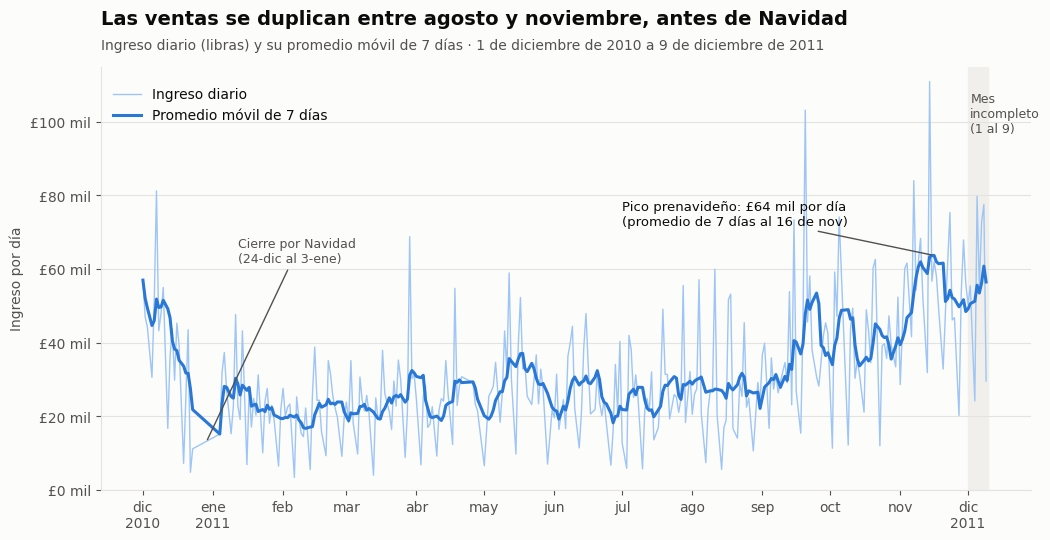

In [61]:
fig, ax = plt.subplots(figsize=(12, 5.5))

# Datos: diario (fondo, claro) y promedio móvil (primer plano)
ax.plot(diario.index, diario.values, color=AZUL_CLARO, linewidth=1, label="Ingreso diario")
ax.plot(media_7d.index, media_7d.values, color=AZUL, linewidth=2.2, label="Promedio móvil de 7 días")

# Contexto: mes incompleto
ax.axvspan(pd.Timestamp("2011-12-01"), diario.index.max() + pd.Timedelta(days=1), color=NEUTRO, zorder=0)
ax.text(pd.Timestamp("2011-12-02"), 108_000, "Mes\nincompleto\n(1 al 9)", fontsize=9, color=TEXTO_2, va="top")

# Anotaciones
ax.annotate(f"Pico prenavideño: £{media_7d.max() / 1000:,.0f} mil por día\n(promedio de 7 días al {pico.day} de {MESES[pico.month - 1]})",
            xy=(pico, media_7d.max()), xytext=(pd.Timestamp("2011-07-01"), 72_000),
            fontsize=9.5, color=TEXTO, arrowprops=dict(arrowstyle="-", color=TEXTO_2, linewidth=1))
ax.annotate("Cierre por Navidad\n(24-dic al 3-ene)",
            xy=(pd.Timestamp("2010-12-29"), 13_000), xytext=(pd.Timestamp("2011-01-12"), 62_000),
            fontsize=9, color=TEXTO_2, arrowprops=dict(arrowstyle="-", color=TEXTO_2, linewidth=1))

# Ejes
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, _: f"{MESES[mdates.num2date(x).month - 1]}\n{mdates.num2date(x).year}"
    if mdates.num2date(x).month in (1, 12) else MESES[mdates.num2date(x).month - 1]))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"£{y / 1000:,.0f} mil"))
ax.set_ylim(0, 115_000)
ax.set_ylabel("Ingreso por día")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(0, 0.98))

titulos(ax, "Las ventas se duplican entre agosto y noviembre, antes de Navidad",
        "Ingreso diario (libras) y su promedio móvil de 7 días · 1 de diciembre de 2010 a 9 de diciembre de 2011")

guardar(fig, "viz1_ventas_en_el_tiempo.png")
plt.show()

## Paso 10: Visualización 2: mapa de calor (día de la semana × hora)

**Técnica.** Un **mapa de calor** (heatmap) muestra una tabla de dos entradas donde cada celda se pinta según su valor: más oscuro, más ingreso. Permite ver de un vistazo **patrones en dos dimensiones a la vez** (aquí, día y hora), que en dos gráficos separados no se verían. Es la técnica de seaborn que vimos en la clase L04. Opciones avanzadas usadas:

- **Escala de color de un solo tono** (azul claro → azul oscuro), creada a medida: como el valor es una cantidad, más oscuro significa más, sin ambigüedad. Una escala "arcoíris" confundiría al lector.
- **Anotación del valor en cada celda**, para leer el número exacto y no depender solo del color (también ayuda a personas con daltonismo).
- **Celdas sin ventas en gris neutro**, distintas de las de valor bajo.

**Preparación de los datos**

| Código | Qué hace |
|---|---|
| `.assign(dia=..., hora=...)` | Agrega dos columnas: día de la semana (`dayofweek`: 0 = lunes) y hora. |
| `.pivot_table(index="dia", columns="hora", values="TotalPrice", aggfunc="sum")` | **Tabla dinámica:** filas = días, columnas = horas, y en cada celda la **suma** del ingreso. Es la matriz que se pinta. |
| `.reindex(range(7))` | Asegura que estén los 7 días, aunque el sábado no tenga ventas (queda vacío, `NaN`). |
| `.reindex(columns=range(6, 21))` | Asegura todas las horas de 6 a 20. |
| `np.where(condición, a, b)` | Para cada celda: si se cumple la condición, pone `a`; si no, `b`. Se usa para escribir el texto de cada celda ("<1" en vez de "0" cuando hay ventas muy pequeñas, y vacío cuando no hay ventas). |

In [62]:
DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

tiempo = ventas.assign(dia=ventas["InvoiceDate"].dt.dayofweek, hora=ventas["InvoiceDate"].dt.hour)
mapa = (tiempo.pivot_table(index="dia", columns="hora", values="TotalPrice", aggfunc="sum")
              .reindex(range(7))
              .reindex(columns=range(6, 21)))
mapa.index = DIAS
mapa_miles = mapa / 1000

etiquetas = np.where(mapa_miles.isna(), "",
                     np.where(mapa_miles < 1, "<1", mapa_miles.round(0).astype("Int64").astype(str)))

print("Ingreso por día (miles de £):")
print(mapa_miles.sum(axis=1).round(0))

Ingreso por día (miles de £):
Lunes       1,655.00
Martes      1,961.00
Miércoles   1,757.00
Jueves      2,080.00
Viernes     1,525.00
Sábado          0.00
Domingo       786.00
dtype: float64


**Construcción de la gráfica**

| Código | Qué hace |
|---|---|
| `LinearSegmentedColormap.from_list(...)` | Crea la escala de color a partir de una lista de azules, del más claro al más oscuro. |
| `escala.set_bad(NEUTRO)` | Color para las celdas vacías (`NaN`): gris neutro. |
| `sns.heatmap(datos, ...)` | Dibuja el mapa de calor. |
| `annot=etiquetas, fmt=""` | Escribe en cada celda el texto preparado (`fmt=""` indica que ya es texto). |
| `linewidths=2, linecolor=FONDO` | Separa las celdas con una línea del color del fondo, para que se distingan. |
| `cbar_kws={...}` | Configura la barra de colores (la leyenda de la escala). |
| `ax.grid(False)` | Apaga la cuadrícula, que en un heatmap se superpondría a las celdas. |

Imagen guardada en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\viz2_mapa_calor_dia_hora.png


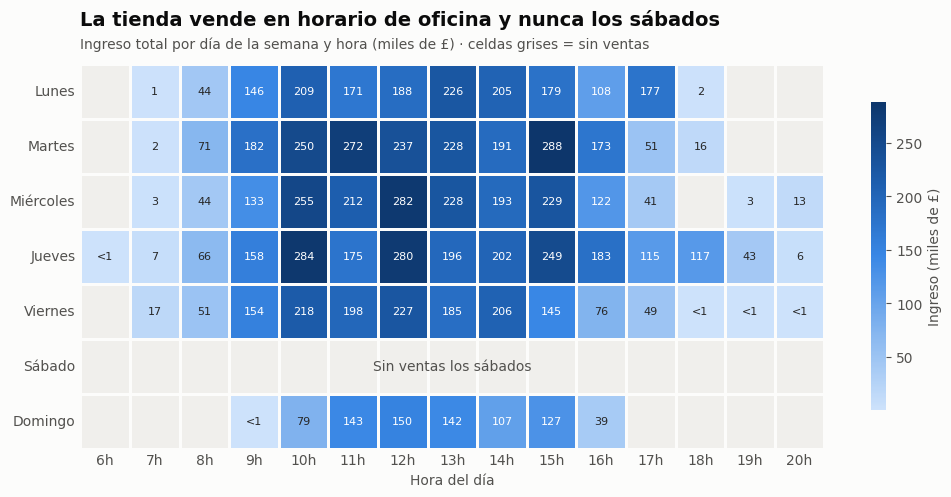

In [63]:
escala = LinearSegmentedColormap.from_list("azules", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
escala.set_bad(NEUTRO)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(mapa_miles, cmap=escala, annot=etiquetas, fmt="", annot_kws={"fontsize": 8},
            linewidths=2, linecolor=FONDO,
            cbar_kws={"label": "Ingreso (miles de £)", "shrink": 0.8}, ax=ax)

ax.grid(False)
ax.text(7.5, 5.5, "Sin ventas los sábados", ha="center", va="center", color=TEXTO_2, fontsize=10)
ax.set_xticklabels([f"{h}h" for h in mapa.columns], rotation=0)
ax.set_yticklabels(DIAS, rotation=0)
ax.set_xlabel("Hora del día")
ax.set_ylabel("")
ax.tick_params(length=0)

titulos(ax, "La tienda vende en horario de oficina y nunca los sábados",
        "Ingreso total por día de la semana y hora (miles de £) · celdas grises = sin ventas")

guardar(fig, "viz2_mapa_calor_dia_hora.png")
plt.show()

## Paso 11: Visualización 3: curva de Pareto (concentración del ingreso)

**Técnica.** El **principio de Pareto** (o regla 80/20) dice que, en muchos fenómenos, una pequeña parte de los elementos explica la mayor parte del resultado. La **curva de Pareto** lo muestra así:

1. Se ordenan los productos (o clientes) **de mayor a menor ingreso**.
2. En el eje X va el **% de productos** acumulado; en el eje Y, el **% del ingreso** que acumulan.
3. Si el ingreso estuviera repartido por igual, la curva sería la **diagonal** (el 20 % de los productos daría el 20 % del ingreso). **Cuanto más se aleja la curva de la diagonal, más concentrado está el ingreso.**

Es una técnica avanzada porque no grafica los datos directamente, sino una **transformación** de ellos (porcentajes acumulados). Permite además **comparar dos dimensiones** (productos y clientes) en la misma escala.

**Preparación de los datos**

| Código | Qué hace |
|---|---|
| `def curva_pareto(serie):` | Función propia que calcula los puntos de la curva para cualquier serie de ingresos. |
| `.sort_values(ascending=False)` | Ordena de mayor a menor. |
| `np.arange(1, n + 1) / n * 100` | Eje X: posición de cada elemento como % del total (1/n, 2/n, ... 100 %). |
| `.cumsum() / .sum() * 100` | Eje Y: **suma acumulada** del ingreso como % del total. |
| `np.searchsorted(x, 20)` | Busca la posición donde el eje X llega al 20 %, para leer cuánto ingreso acumula ese 20 %. |
| `.dropna(subset=["CustomerID"])` | Para los clientes se usan solo las ventas con cliente identificado. |

In [64]:
def curva_pareto(serie):
    ordenada = serie.sort_values(ascending=False)
    x = np.arange(1, len(ordenada) + 1) / len(ordenada) * 100
    y = ordenada.cumsum().values / ordenada.sum() * 100
    return x, y

def ingreso_del_top(x, y, porcentaje):
    return y[np.searchsorted(x, porcentaje)]

ingreso_producto = ventas.groupby("StockCode")["TotalPrice"].sum()
ingreso_cliente  = ventas.dropna(subset=["CustomerID"]).groupby("CustomerID")["TotalPrice"].sum()

x_prod, y_prod = curva_pareto(ingreso_producto)
x_cli,  y_cli  = curva_pareto(ingreso_cliente)

top20_prod = ingreso_del_top(x_prod, y_prod, 20)
top20_cli  = ingreso_del_top(x_cli, y_cli, 20)
top1_cli   = ingreso_del_top(x_cli, y_cli, 1)

print(f"Productos: {len(ingreso_producto):,} · el 20 % genera el {top20_prod:.1f} % del ingreso")
print(f"Clientes:  {len(ingreso_cliente):,} · el 20 % genera el {top20_cli:.1f} % del ingreso")
print(f"El 1 % de los clientes (unos {round(len(ingreso_cliente) * 0.01)}) genera el {top1_cli:.1f} %")

Productos: 3,907 · el 20 % genera el 78.2 % del ingreso
Clientes:  4,324 · el 20 % genera el 73.7 % del ingreso
El 1 % de los clientes (unos 43) genera el 30.2 %


**Construcción de la gráfica**

| Código | Qué hace |
|---|---|
| `ax.plot([0, 100], [0, 100], linestyle="--")` | Dibuja la diagonal de **igualdad perfecta**, como referencia. |
| `ax.plot(x, y, color=..., label=...)` | Una curva por dimensión: productos (azul) y clientes (naranja). |
| `ax.axvline(20)` / `ax.axhline(80)` | Líneas de referencia en el 20 % (eje X) y el 80 % (eje Y): la "regla 80/20". |
| `ax.plot(20, valor, "o", ...)` | Marca con un punto dónde cruza cada curva el 20 %. El borde del color del fondo (`markeredgecolor`) lo separa de la línea. |
| `PercentFormatter()` | Escribe los ejes como porcentajes. |

Imagen guardada en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\viz3_pareto_concentracion.png


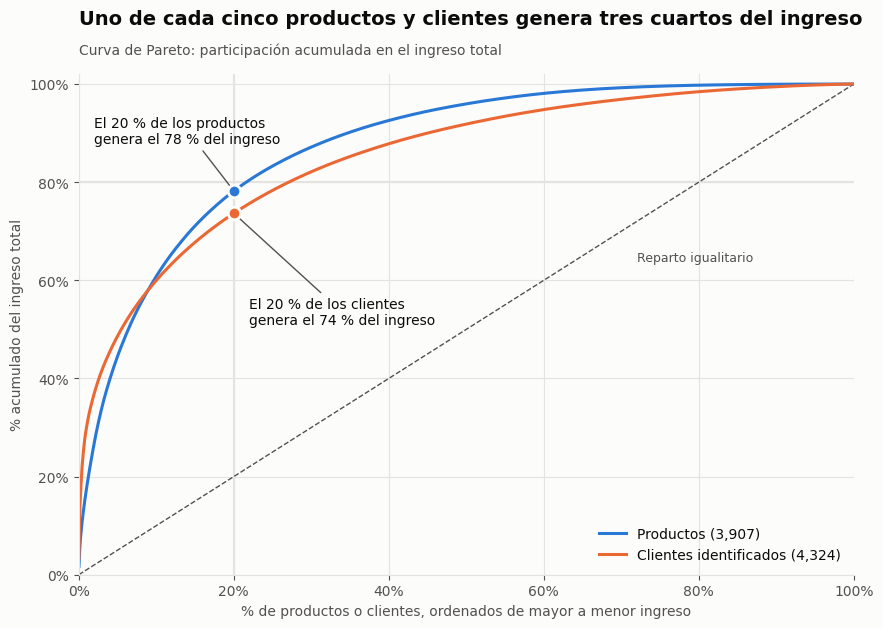

In [65]:
fig, ax = plt.subplots(figsize=(10, 6.5))

ax.plot([0, 100], [0, 100], color=TEXTO_2, linestyle="--", linewidth=1)
ax.text(72, 64, "Reparto igualitario", color=TEXTO_2, fontsize=9, rotation=0)

ax.axvline(20, color=GRILLA, linewidth=1.5, zorder=0)
ax.axhline(80, color=GRILLA, linewidth=1.5, zorder=0)

ax.plot(x_prod, y_prod, color=AZUL,    linewidth=2.2, label=f"Productos ({len(ingreso_producto):,})")
ax.plot(x_cli,  y_cli,  color=NARANJA, linewidth=2.2, label=f"Clientes identificados ({len(ingreso_cliente):,})")

for valor, color in [(top20_prod, AZUL), (top20_cli, NARANJA)]:
    ax.plot(20, valor, "o", color=color, markersize=9, markeredgecolor=FONDO, markeredgewidth=2, zorder=5)

ax.annotate(f"El 20 % de los productos\ngenera el {top20_prod:.0f} % del ingreso",
            xy=(20, top20_prod), xytext=(2, 88), fontsize=10, color=TEXTO,
            arrowprops=dict(arrowstyle="-", color=TEXTO_2, linewidth=1))
ax.annotate(f"El 20 % de los clientes\ngenera el {top20_cli:.0f} % del ingreso",
            xy=(20, top20_cli), xytext=(22, 51), fontsize=10, color=TEXTO,
            arrowprops=dict(arrowstyle="-", color=TEXTO_2, linewidth=1))

ax.xaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
ax.set_xlabel("% de productos o clientes, ordenados de mayor a menor ingreso")
ax.set_ylabel("% acumulado del ingreso total")
ax.legend(loc="lower right", frameon=False)

titulos(ax, "Uno de cada cinco productos y clientes genera tres cuartos del ingreso",
        "Curva de Pareto: participación acumulada en el ingreso total")

guardar(fig, "viz3_pareto_concentracion.png")
plt.show()

## Paso 12: Visualización extra: mapa interactivo (plotly)

**Técnica.** Un **mapa coroplético** pinta cada país según un valor. Se hace con **plotly**, la librería de gráficos **interactivos** de la clase L04: al pasar el mouse por un país aparece su información, y se puede hacer zoom. Como es interactivo, se guarda como **HTML** (se abre en el navegador); las tres imágenes que pide el taller ya están guardadas como PNG.

**Decisión de diseño:** se **excluye el Reino Unido**. Con el 85 % del ingreso, pintaría su país de oscuro y todos los demás quedarían del mismo color claro: el mapa no mostraría nada. El título lo aclara.

| Código | Qué hace |
|---|---|
| `ISO3 = {...}` | Diccionario que traduce los nombres del dataset al **código ISO de 3 letras** que usa plotly para ubicar cada país (por ejemplo, `EIRE` → `IRL`, `RSA` → `ZAF`). |
| `.map(ISO3)` | Reemplaza cada nombre por su código. Los valores que no son países (`Unspecified`, `European Community`, `Channel Islands`) quedan vacíos y se excluyen. |
| `.agg(...)` | Por país: ingreso, clientes y facturas. |
| `px.choropleth(...)` | Crea el mapa: `locations` = códigos, `color` = ingreso, `hover_data` = datos del recuadro al pasar el mouse. |
| `fig.write_html(..., include_plotlyjs="cdn")` | Guarda el mapa como página web. `"cdn"` hace que el archivo sea liviano: la librería se carga desde internet al abrirlo. |

In [128]:
import plotly.express as px

ISO3 = {
    "Australia": "AUS", "Austria": "AUT", "Bahrain": "BHR", "Belgium": "BEL", "Brazil": "BRA",
    "Canada": "CAN", "Cyprus": "CYP", "Czech Republic": "CZE", "Denmark": "DNK", "EIRE": "IRL",
    "Finland": "FIN", "France": "FRA", "Germany": "DEU", "Greece": "GRC", "Hong Kong": "HKG",
    "Iceland": "ISL", "Israel": "ISR", "Italy": "ITA", "Japan": "JPN", "Lebanon": "LBN",
    "Lithuania": "LTU", "Malta": "MLT", "Netherlands": "NLD", "Norway": "NOR", "Poland": "POL",
    "Portugal": "PRT", "RSA": "ZAF", "Saudi Arabia": "SAU", "Singapore": "SGP", "Spain": "ESP",
    "Sweden": "SWE", "Switzerland": "CHE", "USA": "USA", "United Arab Emirates": "ARE",
    "United Kingdom": "GBR",
}

por_pais = (ventas.assign(iso3=ventas["Country"].map(ISO3))
                  .dropna(subset=["iso3"])
                  .query("Country != 'United Kingdom'")
                  .groupby(["Country", "iso3"], as_index=False)
                  .agg(ingreso=("TotalPrice", "sum"),
                       clientes=("CustomerID", "nunique"),
                       facturas=("InvoiceNo", "nunique")))
por_pais["ingreso"] = por_pais["ingreso"].round(0)

fig_mapa = px.choropleth(
    por_pais, locations="iso3", color="ingreso", hover_name="Country",
    hover_data={"iso3": False, "ingreso": ":,.0f", "clientes": True, "facturas": True},
    color_continuous_scale=["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"],
    labels={"ingreso": "Ingreso (£)", "clientes": "Clientes", "facturas": "Facturas"},
    title="Mercado internacional: ingreso por país (sin Reino Unido)",
)
fig_mapa.update_layout(geo=dict(showframe=False, projection_type="natural earth"),
                       paper_bgcolor=FONDO, margin=dict(l=0, r=0, t=50, b=0))

ruta_mapa = BASE_DIR / "viz_extra_mapa_paises.html"
fig_mapa.write_html(ruta_mapa, include_plotlyjs="cdn")
print("Mapa interactivo guardado en:", ruta_mapa)

por_pais.nlargest(8, "ingreso")

Mapa interactivo guardado en: c:\Users\pauls\Desktop\Yachay\2_Fundamentos_ciencia_de_datos\1_taller_fundamentos_cienciadedatos\viz_extra_mapa_paises.html


,Country,iso3,ingreso,clientes,facturas
22,Netherlands,NLD,"283,480.00",9,93
9,EIRE,IRL,"260,756.00",3,279
12,Germany,DEU,"201,459.00",94,443
11,France,FRA,"182,294.00",87,380
0,Australia,AUS,"136,950.00",9,53
31,Switzerland,CHE,"52,487.00",21,48
29,Spain,ESP,"51,765.00",29,87
3,Belgium,BEL,"36,673.00",25,98


In [127]:
fig_mapa.show()

## Paso 13: Verificación de los archivos guardados

In [129]:
for archivo in sorted(BASE_DIR.glob("viz*")):
    print(f"{archivo.name:40s} {archivo.stat().st_size / 1024:8.1f} KB")

viz1_ventas_en_el_tiempo.png                209.2 KB
viz2_mapa_calor_dia_hora.png                107.9 KB
viz3_pareto_concentracion.png               139.8 KB
viz_extra_mapa_paises.html                    9.8 KB
